# Fake News Detection System (DistilBERT Migration)
### M.Sc. Data Science - Minor Project

Welcome to the updated Fake News Detection pipeline! This notebook has been refactored to use a state-of-the-art Hugging Face Transformer model (`DistilBERT`).

**The workflow is broken into 9 main sections:**
1. **Library Imports & Setup:** Installing our deep learning tools.
2. **Data Loading:** Safely loading our local .csv datasets.
3. **Exploratory Data Analysis (EDA):** Graphing Class Distributions and Word Counts.
4. **Dataset Preparation & Tokenization:** Converting raw text into transformer-readable tokens.
5. **Model Initialization:** Loading the pre-trained DistilBERT architecture.
6. **Model Training:** Fine-tuning the transformer on our combined dataset.
7. **Model Evaluation:** Computing Accuracy, Classification Report, and Confusion Matrix.
8. **Model Saving:** Serializing the fine-tuned model for production.
9. **Model Testing & Inference:** Making predictions on new text.

--- 
## 1. Library Imports & Setup
First, we will import all the libraries required for our deep learning task.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# PyTorch & Hugging Face Transformers
import torch
from torch.utils.data import Dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

# Scikit-Learn Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Step 1: All deep learning libraries imported successfully!")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

Step 1: All deep learning libraries imported successfully!
PyTorch Version: 2.11.0+cpu
CUDA Available: False


In [18]:
# Set up universally pretty plot visual styles
sns.set_palette("husl")
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')

--- 
## 2. Data Loading
We use a robust helper function to ingest our heavily populated CSVs while automatically skipping corrupt lines.

In [19]:
# Helper function to read massive CSV files safely
def safe_read_csv(filepath):
    try:
        return pd.read_csv(filepath, engine='python', on_bad_lines='skip')
    except TypeError:
        # For older versions of the pandas library
        return pd.read_csv(filepath, engine='python', error_bad_lines=False)

In [20]:
print("Loading the Global WELFake Dataset...")
welfake_path = 'data/WELFake_Dataset.csv'

df_welfake = safe_read_csv(welfake_path)
df_welfake.columns = df_welfake.columns.str.lower().str.strip()
df_welfake = df_welfake[['text', 'label']].dropna()
df_welfake['source'] = 'WELFake'

# Sample 2000 to manage computer RAM and GPU constraints efficiently for Transformers
# Change the sample size from 2000 to 10000
sample_size = min(10000, len(df_welfake))
df_welfake = df_welfake.sample(sample_size, random_state=42)



print(f"Loaded {len(df_welfake)} rows from WELFake.")

Loading the Global WELFake Dataset...
Loaded 10000 rows from WELFake.


In [21]:
print("Loading the Regional IFND Dataset...")
ifnd_path = 'data/IFND_full.csv'

# We use pd.read_csv directly with 'latin1' encoding to mathematically bypass the error
try:
    df_ifnd = pd.read_csv(ifnd_path, engine='python', on_bad_lines='skip', encoding='latin1')
except TypeError:
    df_ifnd = pd.read_csv(ifnd_path, engine='python', error_bad_lines=False, encoding='latin1')

# Lowercase all headers to standardize
df_ifnd.columns = df_ifnd.columns.str.lower().str.strip()
if 'statement' in df_ifnd.columns:
    df_ifnd = df_ifnd.rename(columns={'statement': 'text'})

df_ifnd = df_ifnd[['text', 'label']].dropna()

# Force string labels into numeric binary classes
def map_clean_labels(x):
    val = str(x).strip().lower()
    if val in ['1', '1.0', 'fake', 'false']: return 1
    if val in ['0', '0.0', 'real', 'true', 'truth']: return 0
    return None

df_ifnd['label'] = df_ifnd['label'].apply(map_clean_labels)
df_ifnd = df_ifnd.dropna()
df_ifnd['source'] = 'IFND'

# Change the sample size from 2000 to 10000
sample_size_ifnd = min(10000, len(df_ifnd))
df_ifnd = df_ifnd.sample(sample_size_ifnd, random_state=42)


print(f"Loaded {len(df_ifnd)} rows from IFND.")

Loading the Regional IFND Dataset...
Loaded 10000 rows from IFND.


In [22]:
df_list = [df_welfake, df_ifnd]
df = pd.concat(df_list, ignore_index=True)

# Ensure strict integer casting for ML compatibility
df['label'] = df['label'].astype(int)

print(f"Combined Master Dataset Length: {len(df)} articles")
df.head()

Combined Master Dataset Length: 20000 articles


,text,label,source
0,Trump s ongoing meltdown over fake news (the...,1,WELFake
1,Women’s Breaststroke: In the days leading up...,0,WELFake
2,It was only a matter of time We can t keep our...,1,WELFake
3,A male colleague grabbing her leg. Another one...,0,WELFake
4,STRASBOURG (Reuters) - The European Parliament...,0,WELFake


--- 
## 3. Exploratory Data Analysis (EDA)
Visualizing class balance and word count density.

C:\Users\vivek\AppData\Local\Temp\ipykernel_14780\3720003509.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0])


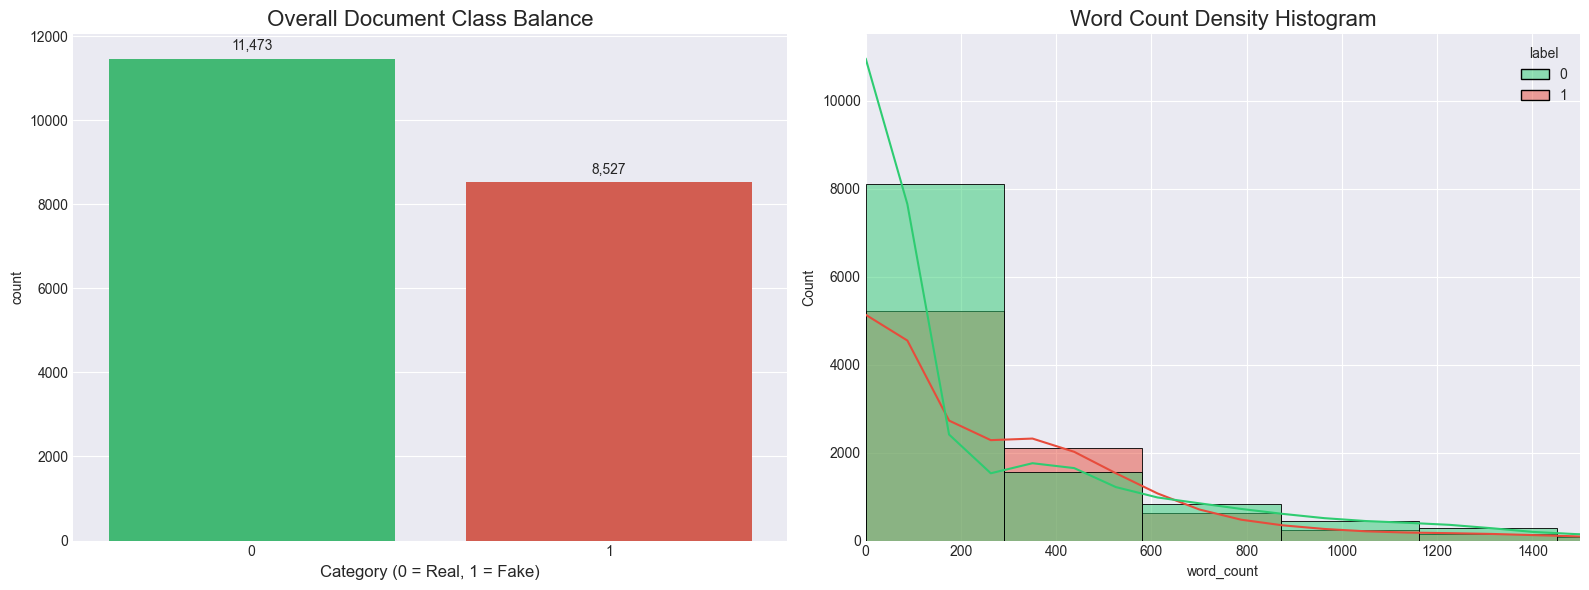

In [ ]:
plt.figure(figsize=(8, 6))

# Modern Class Balance Bar Plot
ax = sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Overall Document Class Balance', fontsize=16)
plt.xlabel('Category (0 = Real, 1 = Fake)', fontsize=12)
plt.ylabel('Document Count', fontsize=12)

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

--- 
## 4. Dataset Preparation & Tokenization
Transformers handle word semantics, context, and grammar inherently, so we do not need to manually remove stopwords or lemmatize. We will use DistilBERT's tokenizer to convert text into token IDs.

In [24]:
# Split the data
X = df['text'].astype(str).tolist()
y = df['label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set Size: {len(X_train)} documents")
print(f"Testing Set Size:  {len(X_test)} documents")

Training Set Size: 16000 documents
Testing Set Size:  4000 documents


In [25]:
# Initialize the DistilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Define a custom PyTorch Dataset
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create Dataset objects
train_dataset = FakeNewsDataset(X_train, y_train, tokenizer)
test_dataset = FakeNewsDataset(X_test, y_test, tokenizer)

print("Datasets created successfully!")

Datasets created successfully!


--- 
## 5. Model Initialization
Loading the DistilBERT sequence classification model.

In [26]:
# Load DistilBERT for Sequence Classification (2 labels: Real or Fake)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
model.to(device)

print(f"Model loaded and moved to {device}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded and moved to cpu


--- 
## 6. Model Training
Fine-tuning the Transformer model using the Hugging Face `Trainer` API.

In [27]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,              # 2 epochs is usually sufficient for fine-tuning
    per_device_train_batch_size=16,  # Reduce to 8 if running out of GPU memory
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [28]:
# Start training! 
print("Starting Transformer fine-tuning...")
trainer.train()

Starting Transformer fine-tuning...


C:\Users\vivek\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.109968,0.111397,0.965750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1000, training_loss=0.21526045799255372, metrics={'train_runtime': 4432.9446, 'train_samples_per_second': 3.609, 'train_steps_per_second': 0.226, 'total_flos': 529869594624000.0, 'train_loss': 0.21526045799255372, 'epoch': 1.0})

--- 
## 7. Model Evaluation
Let's see how our Transformer performs.

C:\Users\vivek\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- DistilBERT Results ---
Overall Accuracy: 96.58%


Classification Report:
              precision    recall  f1-score   support

    REAL (0)       0.96      0.98      0.97      2295
    FAKE (1)       0.98      0.94      0.96      1705

    accuracy                           0.97      4000
   macro avg       0.97      0.96      0.96      4000
weighted avg       0.97      0.97      0.97      4000



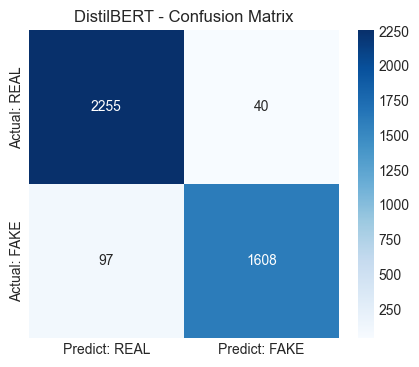

In [29]:
# Make predictions on the test set
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(f"\n{'='*40}")
print(f"--- DistilBERT Results ---")
accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"\n{'='*40}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['REAL (0)', 'FAKE (1)']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predict: REAL', 'Predict: FAKE'], 
            yticklabels=['Actual: REAL', 'Actual: FAKE'])
plt.title('DistilBERT - Confusion Matrix')
plt.show()

--- 
## 8. Model Saving
We save our fine-tuned transformer and its tokenizer for future deployment.

In [30]:
save_directory = 'saved_models/distilbert_fake_news'
os.makedirs(save_directory, exist_ok=True)

# Save the model and tokenizer
model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"Model and tokenizer saved successfully to {save_directory}!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully to saved_models/distilbert_fake_news!


--- 
## 9. Model Testing & Inference
We build an inference function to accept new text and return a confidence-tiered prediction.

In [31]:
import torch.nn.functional as F

def predict_fake_news(news_text, model, tokenizer, device):
    """
    Transformer-based prediction function with confidence scoring.
    """
    if not news_text.strip():
        print("Error: News text cannot be empty.")
        return

    model.eval() # Set model to evaluation mode
    
    # Tokenize input
    inputs = tokenizer(news_text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = F.softmax(logits, dim=-1)
        
    confidence_scores = probabilities[0].cpu().numpy()
    prediction = np.argmax(confidence_scores)
    confidence = confidence_scores[prediction] * 100
    
    print("\n" + "■"*50)
    print("      FAKE NEWS DETECTION SYSTEM REPORT")
    print("■"*50)

    if prediction == 1:
        if confidence > 90:
            verdict = "FAKE NEWS ALERT"
        elif confidence > 75:
            verdict = "SUSPICIOUS"
        else:
            verdict = "AMBIGUOUS: Potential misinformation patterns found."
    else:
        if confidence > 90:
            verdict = "REAL"
        elif confidence > 75:
            verdict = "PROBABLY REAL"
        else:
            verdict = "INCONCLUSIVE"

    print(f"VERDICT      : {verdict}")
    print(f"CONFIDENCE   : {confidence:.2f}%")
    
    if confidence < 70:
        print("SUGGESTION   : Low confidence. Please check cross-referenced sources.")
    elif prediction == 1 and confidence > 85:
        print("BEHAVIOR     : Avoid sharing this until a major agency verifies it.")
    
    print("■"*50 + "\n")

In [32]:
fake_sample = """
EXPOSED: Top government officials have been secretly meeting with pharmaceutical 
companies to develop a mandatory tracking system disguised as a public health 
initiative. Sources who cannot be named have confirmed that the entire vaccination 
program is a front for mass surveillance. Documents obtained exclusively by this 
publication reveal a shocking conspiracy involving billions of taxpayer dollars 
being funneled into this secret project. Wake up people! The mainstream media 
refuses to cover this story because they are part of the cover-up. Share this 
article before it gets taken down by the censors!
"""

real_sample = """
The Reserve Bank of India on Thursday kept the repo rate unchanged at 6.5 percent 
for the eighth consecutive time, in line with market expectations. The monetary 
policy committee voted 4-2 in favour of maintaining the status quo. RBI Governor 
Shaktikanta Das said inflation remains within the target range but food prices 
continue to pose upside risks to the outlook.
"""

print("--- Testing FAKE news sample ---")
predict_fake_news(fake_sample, model, tokenizer, device)

print("--- Testing REAL news sample ---")
predict_fake_news(real_sample, model, tokenizer, device)

--- Testing FAKE news sample ---

■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
      FAKE NEWS DETECTION SYSTEM REPORT
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
VERDICT      : FAKE NEWS ALERT
CONFIDENCE   : 99.82%
BEHAVIOR     : Avoid sharing this until a major agency verifies it.
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■

--- Testing REAL news sample ---

■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
      FAKE NEWS DETECTION SYSTEM REPORT
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
VERDICT      : REAL
CONFIDENCE   : 97.70%
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■

